In [71]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [72]:
df=pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Visualize the whole dataset

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

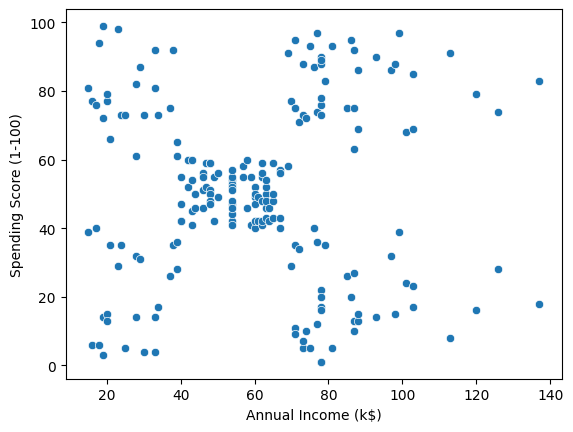

In [73]:
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], data=df)

find K

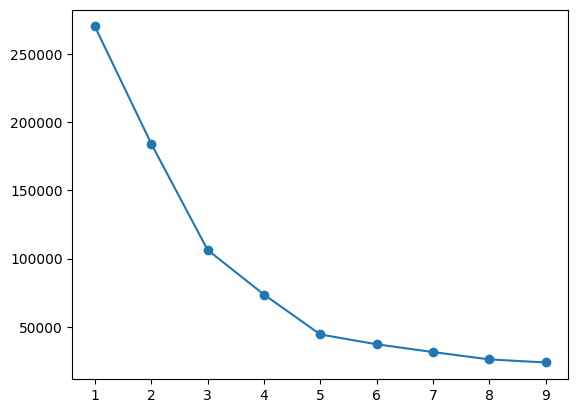

In [75]:
k_range=range(1,10)
sse=[]

for k in k_range:
    km=KMeans(n_clusters=k)
    km.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
    sse.append(km.inertia_)

sse
plt.plot(k_range,sse,marker='o')

K=5

In [76]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


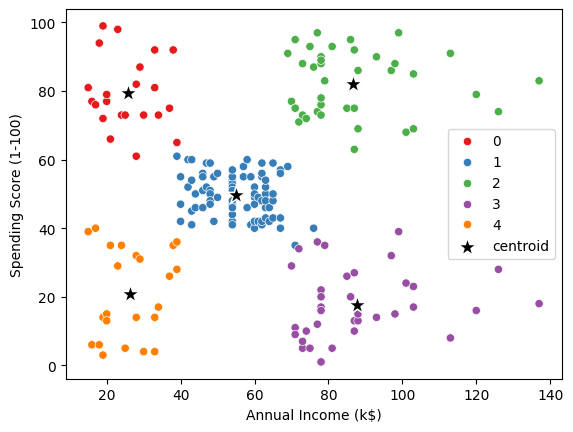

In [78]:
km1=KMeans(n_clusters=5)
Cluster=km1.fit_predict(df[['Annual Income (k$)','Spending Score (1-100)']])
df['cluster']=Cluster
df.head()
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], data=df, hue='cluster', palette='Set1')
sns.scatterplot(x=km1.cluster_centers_[:,0],y=km1.cluster_centers_[:,1],marker='*',s=200,color='black',label='centroid')
plt.legend()

In [82]:
group1=df[df['cluster']==0]
group2=df[df['cluster']==1]
group3=df[df['cluster']==2] 
group4=df[df['cluster']==3]
group5=df[df['cluster']==4]
group2

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
43,44,Female,31,39,61,1
46,47,Female,50,40,55,1
47,48,Female,27,40,47,1
48,49,Female,29,40,42,1
49,50,Female,31,40,42,1
...,...,...,...,...,...,...
120,121,Male,27,67,56,1
121,122,Female,38,67,40,1
122,123,Female,40,69,58,1
126,127,Male,43,71,35,1


In [87]:
df=df.sort_values(by='cluster', ascending=True).reset_index(drop=True)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,32,Female,21,30,73,0
1,30,Female,23,29,87,0
2,24,Male,31,25,73,0
3,22,Male,25,24,73,0
4,8,Female,23,18,94,0
...,...,...,...,...,...,...
195,13,Female,58,20,15,4
196,3,Female,20,16,6,4
197,7,Female,35,18,6,4
198,1,Male,19,15,39,4


In [88]:
df.to_csv('Customer Segmentation.csv',index=False)

Use Min Max Scaler

In [92]:
scaler=MinMaxScaler()
df[['Annual Income (k$)','Spending Score (1-100)']]=scaler.fit_transform(df[['Annual Income (k$)','Spending Score (1-100)']])
df.head()


km1=KMeans(n_clusters=5)
Cluster=km1.fit_predict(df[['Annual Income (k$)','Spending Score (1-100)']])
df['cluster']=Cluster
df.head()
df=df.sort_values(by='cluster',ascending=True).reset_index(drop=True)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,196,Female,35,0.860656,0.795918,0
1,190,Female,36,0.721311,0.857143,0
2,186,Male,30,0.688525,0.979592,0
3,188,Male,28,0.704918,0.683673,0
4,172,Male,28,0.590164,0.755102,0
...,...,...,...,...,...,...
195,13,Female,58,0.040984,0.142857,4
196,3,Female,20,0.008197,0.051020,4
197,7,Female,35,0.024590,0.051020,4
198,1,Male,19,0.000000,0.387755,4


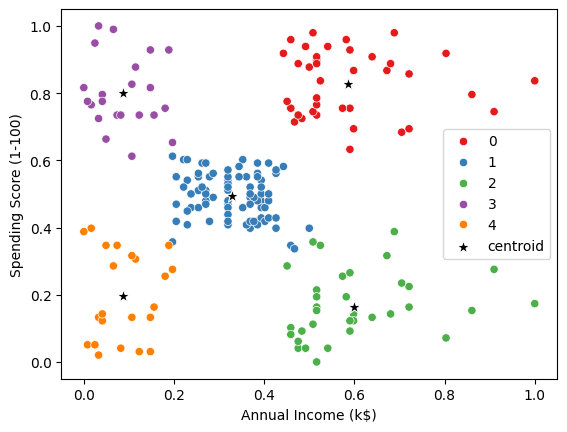

In [93]:
sns.scatterplot(x=df['Annual Income (k$)'], data=df, y=df['Spending Score (1-100)'], hue=df['cluster'], palette='Set1')
sns.scatterplot(x=km1.cluster_centers_[:,0],y=km1.cluster_centers_[:,1], marker='*',s=100,color='black',label='centroid')
plt.legend()

In [94]:
df.to_csv('Customer_Segmentation(Using Min Max Scaler).csv', index=False)